# Combined PT Results

This notebook aggregates all notebooks under `diagnosis/pt` and builds:

- A unified comparison table (rows = notebook/dataset, columns = `default bart`, `pt`, `tabpfn`) using run-averaged RMSE.
- A CRPS comparison table (`default bart` vs `pt`) using run-averaged CRPS.
- Boxplots for both comparisons.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd

PT_DIR = Path('.')
STORE_DIR = PT_DIR / 'store'

if not STORE_DIR.exists():
    raise FileNotFoundError(f'Cannot find store directory: {STORE_DIR.resolve()}')

NOTEBOOK_FILES = sorted(
    p for p in PT_DIR.glob('*_pt.ipynb')
    if p.name != 'combined_results.ipynb'
)

if not NOTEBOOK_FILES:
    raise RuntimeError('No *_pt.ipynb notebooks found under diagnosis/pt.')

def read_numeric_values(metric_dir: Path, setting_tag: str, model: str, metric_name: str):
    pattern = f'{setting_tag}__run*__{model}__{metric_name}.csv'
    files = sorted(metric_dir.glob(pattern))
    vals = []
    for f in files:
        arr = np.loadtxt(f, delimiter=',', comments='#')
        arr = np.asarray(arr).reshape(-1)
        if arr.size > 0:
            vals.append(float(arr[0]))
    return vals

TABPFN_ROW_RE = re.compile(
    r'^\s*(\d+)\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*$'
)

def _load_notebook_json(notebook_path: Path):
    # utf-8-sig transparently handles files with UTF-8 BOM.
    with open(notebook_path, 'r', encoding='utf-8-sig') as f:
        try:
            return json.load(f)
        except json.JSONDecodeError:
            # Fallback: read raw text, strip BOM if present, then decode JSON.
            f.seek(0)
            raw = f.read()
            return json.loads(raw.lstrip('\ufeff'))

def extract_tabpfn_rmse_runs(notebook_path: Path):
    nb = _load_notebook_json(notebook_path)

    for cell in nb.get('cells', []):
        for output in cell.get('outputs', []):
            text_block = None

            data = output.get('data', {})
            if 'text/plain' in data:
                plain = data['text/plain']
                if isinstance(plain, list):
                    text_block = ''.join(plain)
                else:
                    text_block = str(plain)
            elif 'text' in output:
                t = output['text']
                text_block = ''.join(t) if isinstance(t, list) else str(t)

            if not text_block:
                continue

            if 'default bart' in text_block and 'tabpfn' in text_block:
                tabpfn_vals = []
                for line in text_block.splitlines():
                    m = TABPFN_ROW_RE.match(line)
                    if m:
                        tabpfn_vals.append(float(m.group(4)))
                if tabpfn_vals:
                    return tabpfn_vals

    return []

In [2]:
records = []
run_level_records = []

for nb_path in NOTEBOOK_FILES:
    setting_tag = nb_path.stem
    dataset_name = setting_tag.replace('_pt', '')

    rmse_default_runs = read_numeric_values(STORE_DIR / 'subsample_rmse', setting_tag, 'default', 'subsample_rmse')
    rmse_pt_runs = read_numeric_values(STORE_DIR / 'subsample_rmse', setting_tag, 'pt', 'subsample_rmse')
    crps_default_runs = read_numeric_values(STORE_DIR / 'subsample_crps', setting_tag, 'default', 'subsample_crps')
    crps_pt_runs = read_numeric_values(STORE_DIR / 'subsample_crps', setting_tag, 'pt', 'subsample_crps')
    rmse_tabpfn_runs = extract_tabpfn_rmse_runs(nb_path)

    rmse_default_mean = float(np.mean(rmse_default_runs)) if rmse_default_runs else np.nan
    rmse_pt_mean = float(np.mean(rmse_pt_runs)) if rmse_pt_runs else np.nan
    rmse_tabpfn_mean = float(np.mean(rmse_tabpfn_runs)) if rmse_tabpfn_runs else np.nan
    crps_default_mean = float(np.mean(crps_default_runs)) if crps_default_runs else np.nan
    crps_pt_mean = float(np.mean(crps_pt_runs)) if crps_pt_runs else np.nan

    records.append({
        'notebook': setting_tag,
        'default bart': rmse_default_mean,
        'pt': rmse_pt_mean,
        'tabpfn': rmse_tabpfn_mean,
        'crps_default': crps_default_mean,
        'crps_pt': crps_pt_mean,
        'n_runs_rmse_default': len(rmse_default_runs),
        'n_runs_rmse_pt': len(rmse_pt_runs),
        'n_runs_rmse_tabpfn': len(rmse_tabpfn_runs),
        'n_runs_crps_default': len(crps_default_runs),
        'n_runs_crps_pt': len(crps_pt_runs),
    })

    max_rmse_runs = max(len(rmse_default_runs), len(rmse_pt_runs), len(rmse_tabpfn_runs))
    for run_idx in range(max_rmse_runs):
        if run_idx < len(rmse_default_runs):
            run_level_records.append({
                'dataset': dataset_name,
                'notebook': setting_tag,
                'run_id': run_idx,
                'metric': 'RMSE',
                'model': 'default bart',
                'value': rmse_default_runs[run_idx],
            })
        if run_idx < len(rmse_pt_runs):
            run_level_records.append({
                'dataset': dataset_name,
                'notebook': setting_tag,
                'run_id': run_idx,
                'metric': 'RMSE',
                'model': 'pt',
                'value': rmse_pt_runs[run_idx],
            })
        if run_idx < len(rmse_tabpfn_runs):
            run_level_records.append({
                'dataset': dataset_name,
                'notebook': setting_tag,
                'run_id': run_idx,
                'metric': 'RMSE',
                'model': 'tabpfn',
                'value': rmse_tabpfn_runs[run_idx],
            })

    max_crps_runs = max(len(crps_default_runs), len(crps_pt_runs))
    for run_idx in range(max_crps_runs):
        if run_idx < len(crps_default_runs):
            run_level_records.append({
                'dataset': dataset_name,
                'notebook': setting_tag,
                'run_id': run_idx,
                'metric': 'CRPS',
                'model': 'default bart',
                'value': crps_default_runs[run_idx],
            })
        if run_idx < len(crps_pt_runs):
            run_level_records.append({
                'dataset': dataset_name,
                'notebook': setting_tag,
                'run_id': run_idx,
                'metric': 'CRPS',
                'model': 'pt',
                'value': crps_pt_runs[run_idx],
            })

summary_df = pd.DataFrame(records).sort_values('notebook').reset_index(drop=True)
run_df = pd.DataFrame(run_level_records)

rmse_table = summary_df[['notebook', 'default bart', 'pt', 'tabpfn']].copy()
crps_table = summary_df[['notebook', 'crps_default', 'crps_pt']].rename(columns={
    'crps_default': 'default bart',
    'crps_pt': 'pt',
})

print('Unified RMSE table (run-averaged):')
display(rmse_table)

print('Unified CRPS table (run-averaged, default vs pt):')
display(crps_table)

Unified RMSE table (run-averaged):


,notebook,default bart,pt,tabpfn
0,real1_Abalone_pt,2.170838,2.094237,1.914861
1,real2_WineQuality_pt,0.679681,0.690771,0.593167
2,real3_CalHousing_pt,0.591941,0.590478,0.459430
3,real4_Concrete_pt,5.737525,6.275702,4.021943
4,real5_BreastTumor_pt,9.750464,9.832671,9.637458
5,real6_echoMonths_pt,11.571699,11.591007,11.526234
6,real7_Satellite_pt,0.842412,0.842990,0.623531
7,real8_Boston_pt,3.469322,3.429174,2.452145
8,real9_Diabetes_pt,57.242442,55.852297,54.753049
9,syn1_Friedman_pt,1.440416,1.369980,1.059244


Unified CRPS table (run-averaged, default vs pt):


,notebook,default bart,pt
0,real1_Abalone_pt,1.159141,1.131382
1,real2_WineQuality_pt,0.375290,0.383614
2,real3_CalHousing_pt,0.317181,0.321646
3,real4_Concrete_pt,3.022544,3.489894
4,real5_BreastTumor_pt,5.465792,5.514447
5,real6_echoMonths_pt,6.553364,6.556428
6,real7_Satellite_pt,0.407943,0.429620
7,real8_Boston_pt,1.849003,1.869795
8,real9_Diabetes_pt,32.430337,31.780154
9,syn1_Friedman_pt,0.817080,0.818710


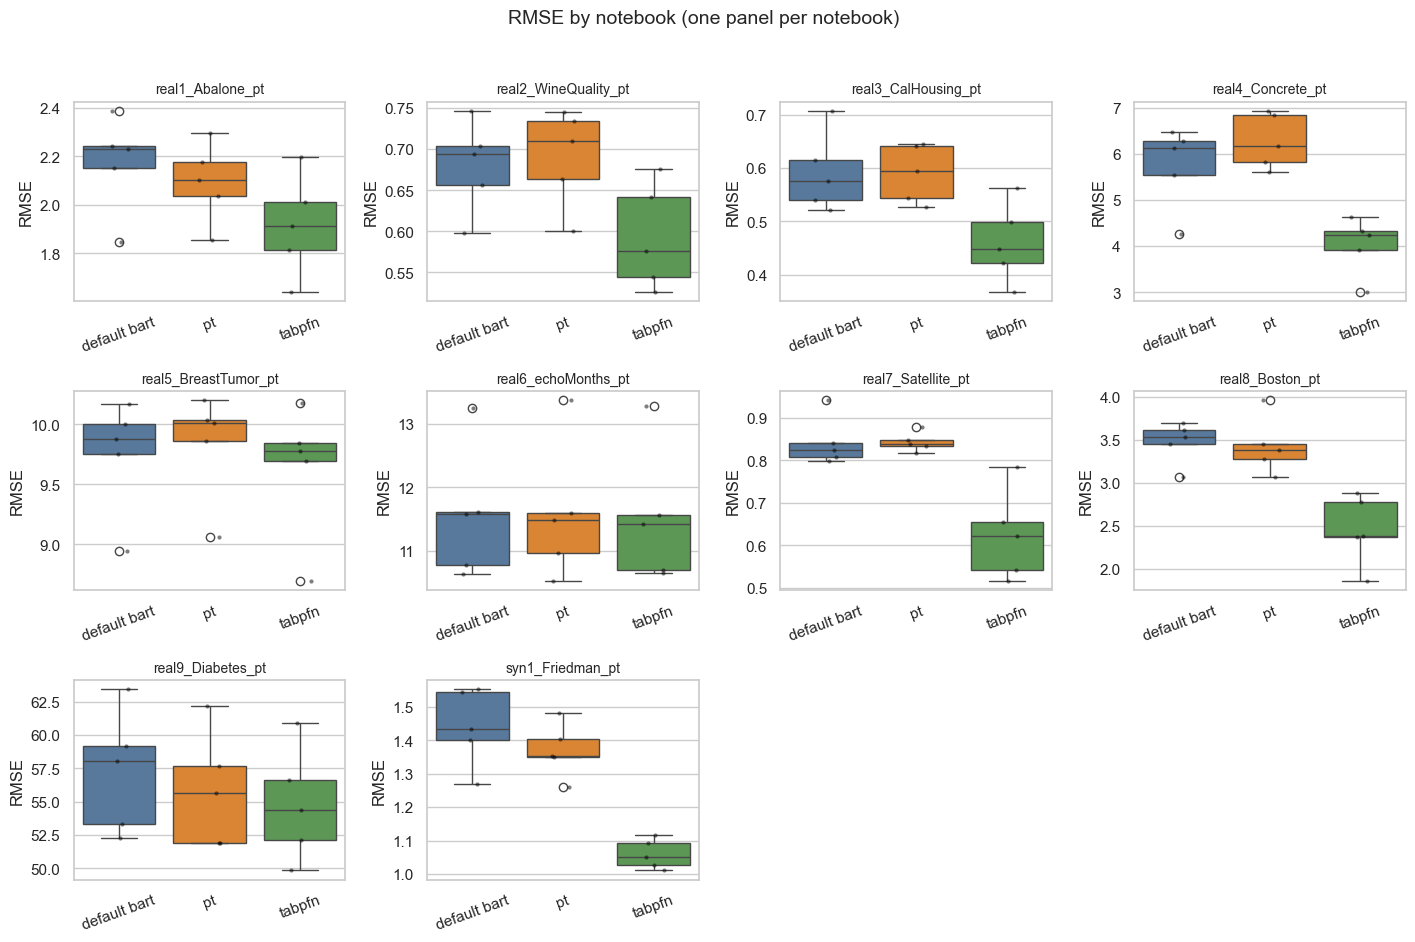

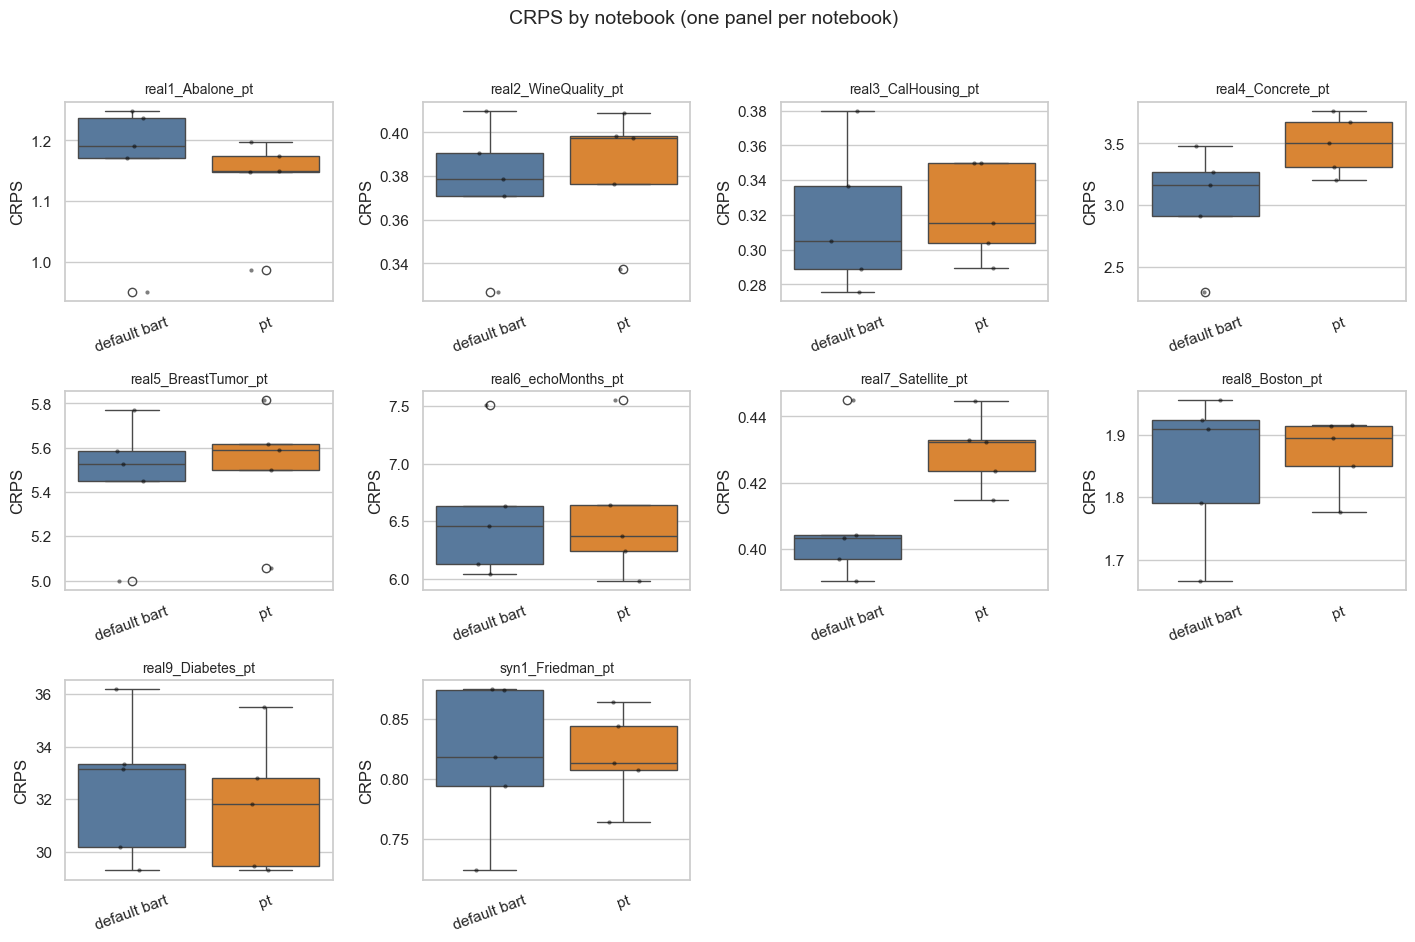

In [3]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

notebook_order = rmse_table['notebook'].tolist()

def plot_faceted_boxplots(data, models, title, y_label, palette, ncols=4, figsize_per_panel=(3.6, 3.2)):
    nb_names = list(notebook_order)
    n = len(nb_names)
    ncols = max(1, ncols)
    nrows = math.ceil(n / ncols)

    palette_map = {m: palette[i] for i, m in enumerate(models)}

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    for i, nb in enumerate(nb_names):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        sub = data[data['notebook'] == nb]

        sns.boxplot(
            data=sub,
            x='model',
            y='value',
            order=models,
            hue='model',
            hue_order=models,
            palette=palette_map,
            dodge=False,
            ax=ax,
        )
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

        sns.stripplot(
            data=sub,
            x='model',
            y='value',
            order=models,
            color='black',
            alpha=0.5,
            size=3,
            jitter=0.12,
            ax=ax,
        )

        ax.set_title(nb, fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel(y_label)
        ax.tick_params(axis='x', labelrotation=20)

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# RMSE faceted plots: one small panel per notebook, with 3 method boxes
rmse_by_nb = run_df[
    (run_df['metric'] == 'RMSE')
    & (run_df['model'].isin(['default bart', 'pt', 'tabpfn']))
]

plot_faceted_boxplots(
    data=rmse_by_nb,
    models=['default bart', 'pt', 'tabpfn'],
    title='RMSE by notebook (one panel per notebook)',
    y_label='RMSE',
    palette=['#4C78A8', '#F58518', '#54A24B'],
    ncols=4,
 )

# CRPS faceted plots: one small panel per notebook, with 2 method boxes
crps_by_nb = run_df[
    (run_df['metric'] == 'CRPS')
    & (run_df['model'].isin(['default bart', 'pt']))
]

plot_faceted_boxplots(
    data=crps_by_nb,
    models=['default bart', 'pt'],
    title='CRPS by notebook (one panel per notebook)',
    y_label='CRPS',
    palette=['#4C78A8', '#F58518'],
    ncols=4,
 )

## PCA Summary Montage

This section reuses the saved PCA-visualization outputs from each individual notebook and arranges them into faceted overview figures:
- PC1 histogram + KDE
- PC1 vs PC2 scatter (with default/pt samples and tabpfn/y points as rendered in each notebook).

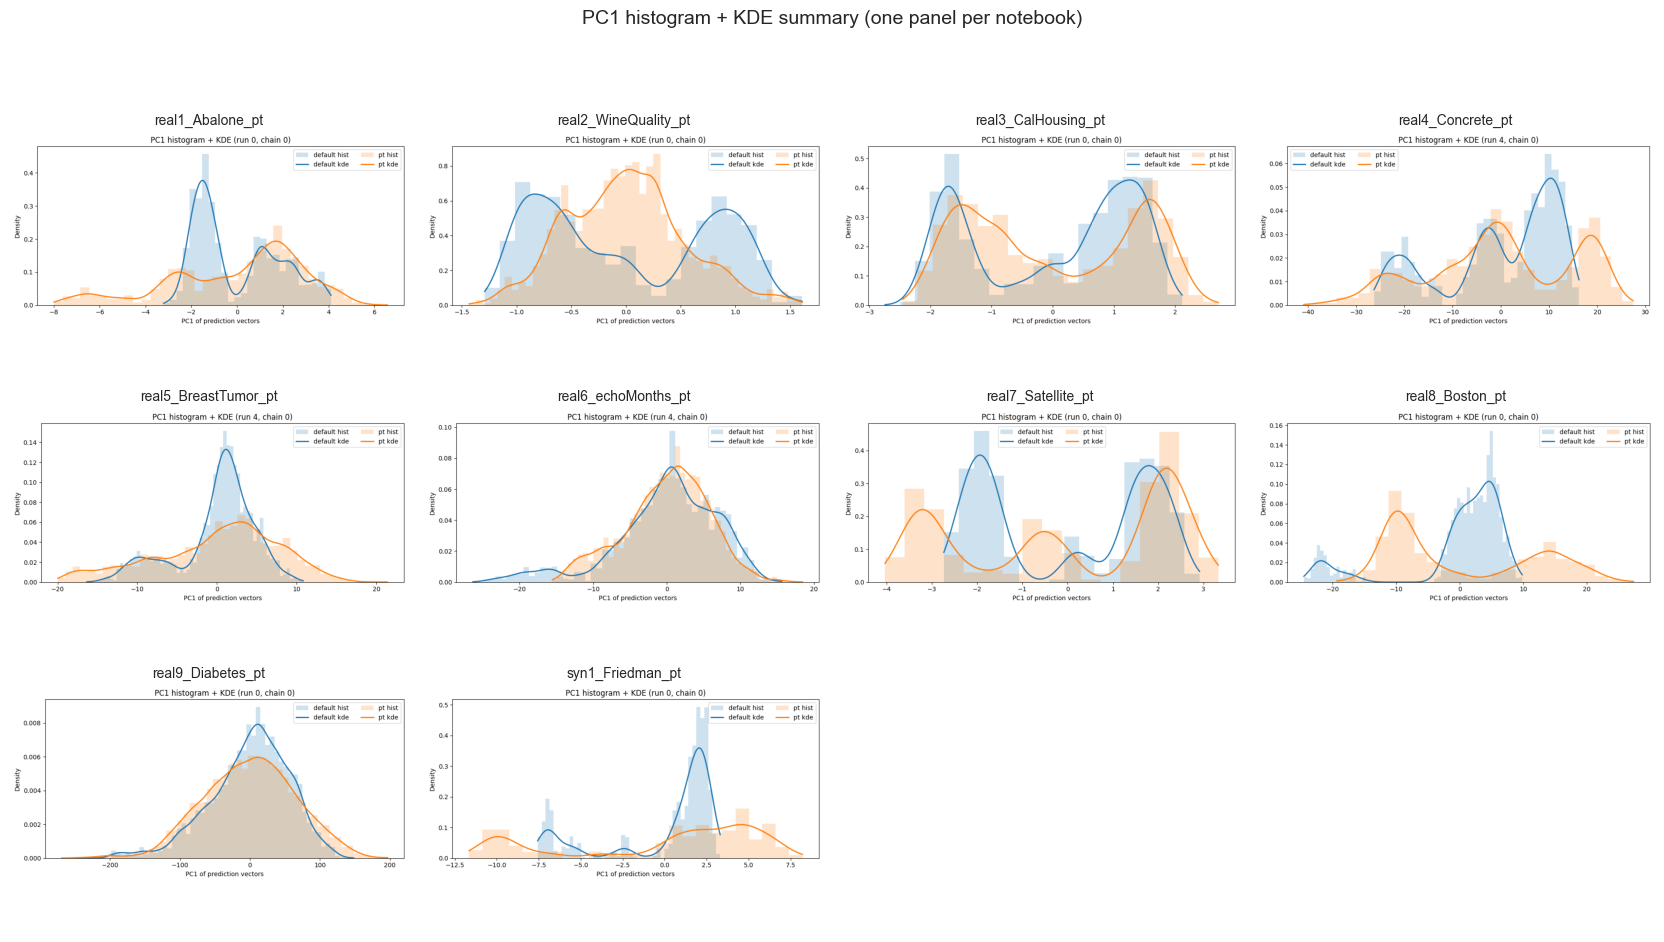

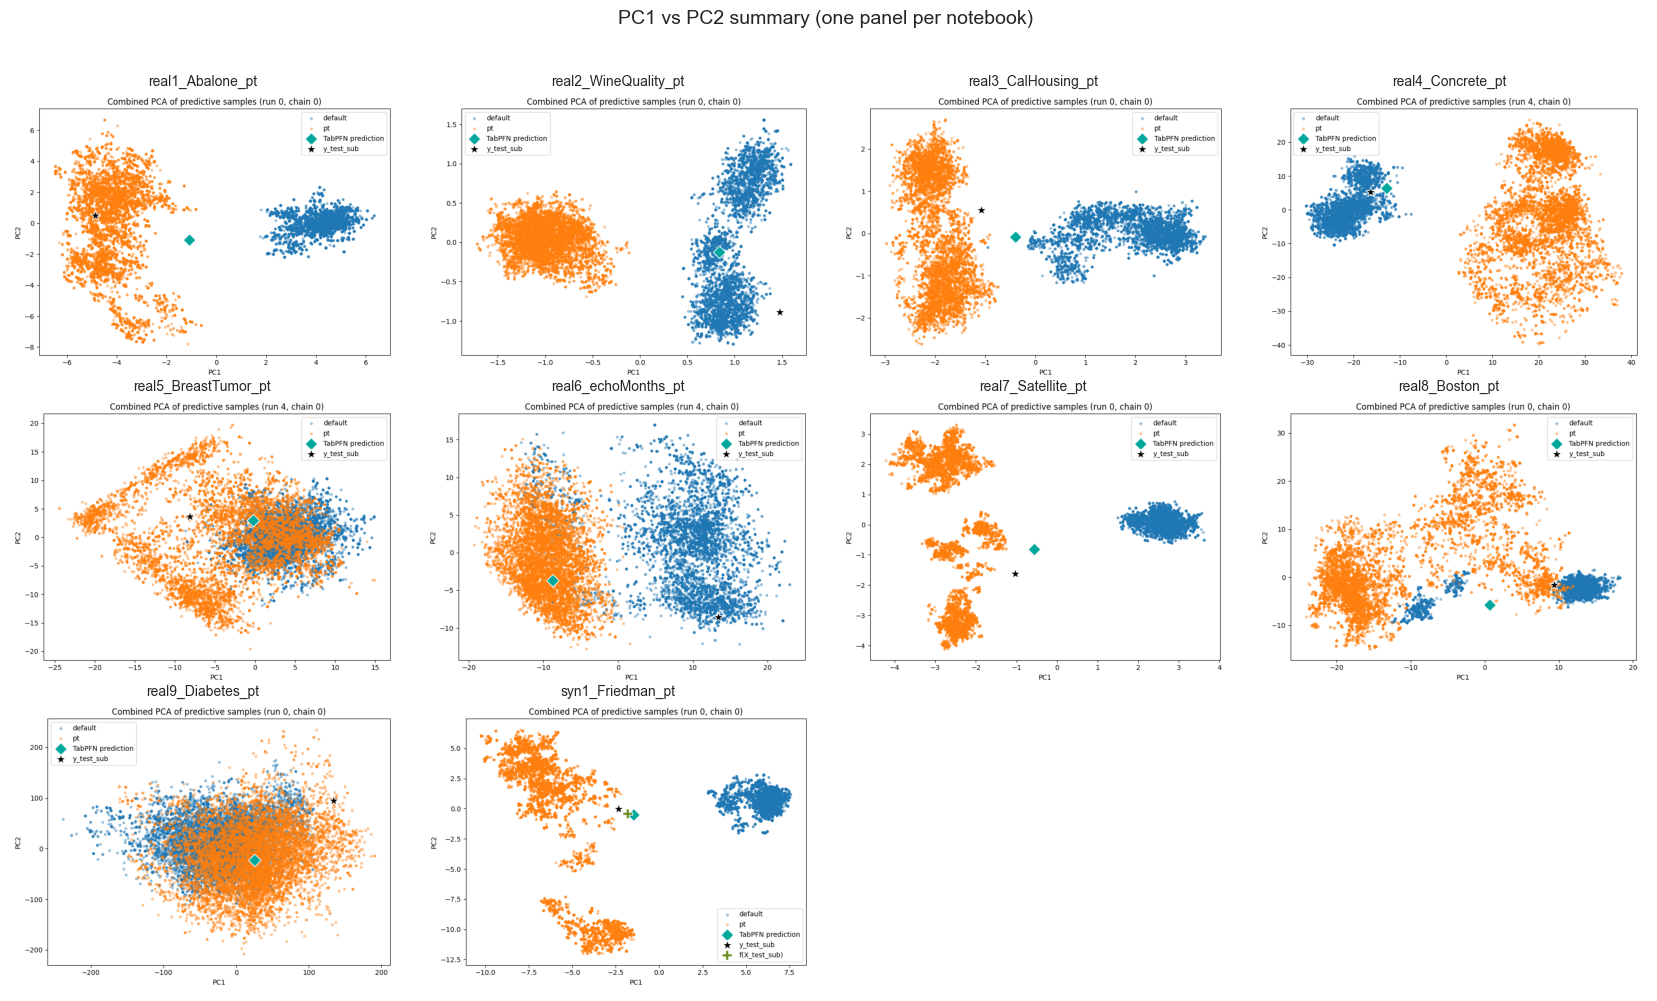

In [4]:
import base64
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PT_DIR = Path('.')

def _load_nb_json(path: Path):
    with open(path, 'r', encoding='utf-8-sig') as f:
        return json.load(f)

def _decode_png_to_array(png_data):
    if isinstance(png_data, list):
        png_data = ''.join(png_data)
    if isinstance(png_data, bytes):
        raw = png_data
    else:
        raw = base64.b64decode(png_data)
    return plt.imread(io.BytesIO(raw), format='png')

def _extract_hist_scatter_images(nb_path: Path):
    nb = _load_nb_json(nb_path)
    for cell in nb.get('cells', []):
        if cell.get('cell_type') != 'code':
            continue
        src = '\n'.join(cell.get('source', []))
        if 'PC1 histogram + KDE' not in src or 'Combined PCA: PC1 vs PC2 scatter' not in src:
            continue

        imgs = []
        for out in cell.get('outputs', []):
            data = out.get('data', {}) if isinstance(out, dict) else {}
            if 'image/png' in data:
                imgs.append(_decode_png_to_array(data['image/png']))

        # In your notebook this cell emits 3 images: [PC1 trace, hist+kde, PC1vsPC2 scatter]
        if len(imgs) >= 3:
            return imgs[1], imgs[2]
        if len(imgs) == 2:
            return imgs[0], imgs[1]
        if len(imgs) == 1:
            return None, imgs[0]

    return None, None

def _plot_image_grid(image_map, title, ncols=4, panel_size=(4.0, 3.2)):
    names = list(image_map.keys())
    n = len(names)
    ncols = max(1, ncols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_size[0] * ncols, panel_size[1] * nrows),
        squeeze=False,
    )

    for i, name in enumerate(names):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        img = image_map[name]
        if img is None:
            ax.text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=10)
            ax.set_facecolor('#f5f5f5')
        else:
            ax.imshow(img)
        ax.set_title(name, fontsize=10)
        ax.axis('off')

    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].axis('off')

    fig.suptitle(title, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

nb_files = sorted(
    p for p in PT_DIR.glob('*_pt.ipynb')
    if p.name != 'combined_results.ipynb'
)

hist_images = {}
scatter_images = {}
for p in nb_files:
    hist_img, scatter_img = _extract_hist_scatter_images(p)
    hist_images[p.stem] = hist_img
    scatter_images[p.stem] = scatter_img

_plot_image_grid(
    hist_images,
    title='PC1 histogram + KDE summary (one panel per notebook)',
    ncols=4,
    panel_size=(4.2, 3.2),
)

_plot_image_grid(
    scatter_images,
    title='PC1 vs PC2 summary (one panel per notebook)',
    ncols=4,
    panel_size=(4.2, 3.4),
)